In [2]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
PREDSDIR  = CONFIGS['filepaths']['predictions']
LATRANGE  = CONFIGS['domain']['latrange']
LONRANGE  = CONFIGS['domain']['lonrange']
MODELS    = CONFIGS['experiments']
SPLIT     = 'test'

MODELDICT = {}
for name,rc in MODELS['sr']['optimizedeqs'].items():
    MODELDICT[name] = {'label':rc['description'],'color':rc['color'],'marker':'o'}

In [4]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

results = {}
for name in MODELDICT:
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):
        continue
    with xr.open_dataset(filepath) as ds:
        predtp = ds.tp.load()
    if 'seed' in predtp.dims:
        predtp = predtp.mean('seed')
    if 'complexity' in predtp.dims:
        predtp = predtp.isel(complexity=0)
    ytrue,ypred   = xr.align(truetp,predtp,join='inner')
    results[name] = (ytrue.squeeze(),ypred.squeeze())

print(f'Loaded {len(results)}/{len(MODELDICT)} models!')

Loaded 4/4 models!


In [5]:
def exceedance_curve(arr):
    flat = arr.ravel()
    flat = flat[np.isfinite(flat)&(flat>0)]
    flat = np.sort(flat)
    prob = np.arange(len(flat),0,-1)/len(flat)
    return flat,prob

obs = next(iter(results.values()))[0]
obsvalues,obsprob = exceedance_curve(obs.values)

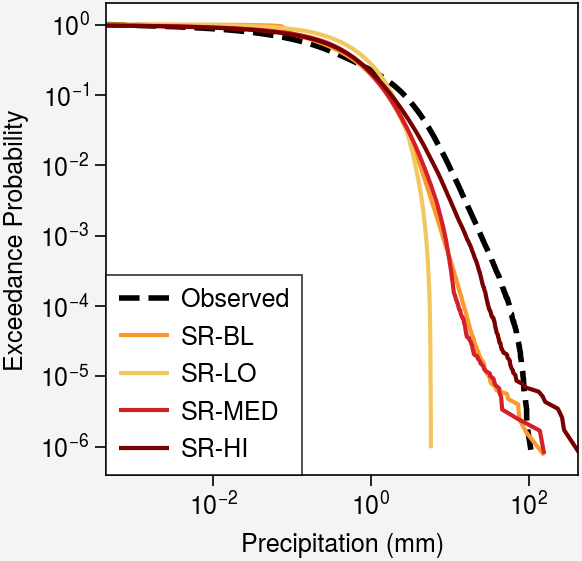

In [6]:
fig,ax = pplt.subplots(figwidth=3)
ax.plot(obsvalues,obsprob,color='k',linestyle='--',linewidth=2,label='Observed',zorder=0)
for name,info in MODELDICT.items():
    if name not in results:continue
    predvalues,predprob = exceedance_curve(results[name][1].values)
    ax.plot(predvalues,predprob,color=info['color'],linewidth=1.5,label=info['label'])
ax.format(grid=False,xlabel='Precipitation (mm)',xscale='log',xformatter='log',
          ylabel='Exceedance Probability',yscale='log',yformatter='log')
ax.legend(loc='ll',ncols=1)
pplt.show()
fig.save('../figs/fig_4.jpg')